In [386]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as colors
import matplotlib.ticker as mtick
import matplotlib.lines as mlines

In [ ]:
resultado = pd.read_csv('C:\\Users\\Lenovo\\OneDrive\\Documentos\\André Luis\\1. UFMG\\TCC\\TCC\\Resultados\\Resultados\\resultado_final.csv').drop(columns=['Unnamed: 0'])

df = resultado
df['custo fixo'] = 250
df['custo total'] = df['custo fixo'] + df['custo total das rotas']

grouped = df.groupby(['num', 'instancia', 'dia']).aggregate({'custo fixo': 'sum', 'numero de rotas': 'sum', 'custo total das rotas': 'sum', 'custo total': 'sum', 'tempo médio por rota': 'mean', 'custo maximo de rota': 'max', 'frete medio': 'mean', 'clientes': 'sum', 'frete maximo': 'max', 'frete minimo': 'min'}).reset_index()
final = grouped.reset_index().groupby('num').mean().reset_index()

df.to_csv('C:\\Users\\Lenovo\\OneDrive\\Documentos\\André Luis\\1. UFMG\\TCC\\TCC\\Resultados\\Resultados\\resultado_raw.csv')
grouped.to_csv('C:\\Users\\Lenovo\\OneDrive\\Documentos\\André Luis\\1. UFMG\\TCC\\TCC\\Resultados\\Resultados\\resultado_por_instancia.csv')
final.to_csv('C:\\Users\\Lenovo\\OneDrive\\Documentos\\André Luis\\1. UFMG\\TCC\\TCC\\Resultados\\Resultados\\resultado_agrupado.csv')

In [ ]:
grouped.sort_values(by='num')
df = grouped.sort_values(by='custo total')[1:]
df = df.sort_values(by = 'instancia')

freteRef = df[['num', 'frete medio']][df['clientes']==1543].sort_values('num').reset_index()
veiculosRef = df[['num', 'numero de rotas']][df['clientes']==1543].sort_values('num').reset_index()
df = df.reset_index().drop(columns='index')

df['freteRef'] = ''
df['veiculosRef'] = ''
df['dif_frete'] = ''
df['dif_veiculos'] = ''
df['dif_clientes'] = ''
df['taxa_atendimento'] = ''
for i, row in df.iterrows():
    df['freteRef'][i] = freteRef['frete medio'][freteRef['num']==row['num']].iloc[0]
    df['veiculosRef'][i] = veiculosRef['numero de rotas'][freteRef['num']==row['num']].iloc[0]
    df['dif_frete'][i] = df['freteRef'][i] - df['frete medio'][i]
    df['dif_veiculos'][i] = df['veiculosRef'][i] - df['numero de rotas'][i]
    df['dif_clientes'][i] = df['clientes'][i]/df['numero de rotas'][i]*df['dif_veiculos'][i]
    if df['dif_clientes'][i] < 0:
        df['taxa_atendimento'][i] = 1-df['dif_clientes'][i]*(-1)/df['clientes'][i]
    else:
        df['taxa_atendimento'][i] = 1
# df

### Scatter

In [ ]:
# Extract the required columns
x = df['instancia']
y = df['numero de rotas']
nums = df['num']

# Create colormap with skipping white color
cmap = cm.get_cmap('bone')
cmap = colors.ListedColormap([cmap(i) for i in range(0, cmap.N-100)])
norm = colors.Normalize(vmin=nums.min(), vmax=nums.max())

# Create scatter plot with consistent color pattern
scatter = plt.scatter(x, y, c=nums, cmap=cmap, norm=norm)


# Calculate mean values for each 'num' category
mean_values = df.groupby('num')['numero de rotas'].mean()

# Add mean lines
for num, mean_value in mean_values.items():
    plt.axhline(mean_value, color=cmap(norm(num)), linestyle='--', label=f'Mean ({mean_value})')
    plt.text(+5.3, mean_value, f'{mean_value:.2f}', color=cmap(norm(num)), ha='left', va='center')

# Add axis labels and a title
plt.xlabel('Instância')
plt.ylabel('Quantidade de veículos')
plt.title('Quantidade de veículos por cenário e instância para os 30 dias')

# Create legend
legend_elements = []
for num in np.sort(nums.unique())[::-1]:
    legend_elements.append(plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=cmap(norm(num)), markersize=8, label=f'cenário = {num}'))
legend_elements.append(plt.Line2D([0], [0], color='gray', linestyle='--', label='Média'))
plt.legend(handles=legend_elements)

# Display the plot
plt.show()

### Boxplot

In [ ]:
# Create a dictionary to store the data for each 'num' category
data = {}
for num in np.sort(df['num'].unique())[::-1]:
    data[num] = df[df['num'] == num]['dif_frete'].values

# Create a list to store the boxplot labels
labels = [f'{num}' for num in data.keys()]

# Create the boxplot
fig, axes = plt.subplots()
medianprops = dict(linestyle='-', linewidth=1.5, color='orange')
bplot = axes.boxplot(data.values(), labels=labels, vert=False, showmeans=True, medianprops=medianprops)

# Add legend
legend_elements = []
legend_elements.append(plt.Line2D([0], [0], color='orange', linestyle='-', label='Mediana'))
legend_elements.append(mlines.Line2D([], [], color='green', marker='^', linestyle='None',
                          markersize=6, label='Média'))
plt.legend(handles=legend_elements)

# Fill with colors
values = list(data.keys())
cmap = cm.get_cmap('bone')
cmap = colors.ListedColormap([cmap(i) for i in range(0, cmap.N-100)])
rescale = lambda values: (values - np.min(values)) / (np.max(values) - np.min(values))
for patch, color in zip(bplot['boxes'], cmap(rescale(values))):
    patch.set(color=color, fillstyle='full')

plt.axvline(0, color='gray', linestyle='--')

# Add axis labels and a title
plt.xlabel('Diferença de frete')
plt.ylabel('Cenário')
plt.title('Avaliação da diferença de frete por cenário')

# Add labels for mean values
means = bplot['means']
for mean in means:
    mean_xvalue = mean.get_xdata()[0]
    mean_yvalue = mean.get_ydata()[0]
    axes.annotate(f'R$ {mean_xvalue:.2f}', xy=(mean_xvalue, mean_yvalue), xytext=(0, 22),
                  textcoords='offset points', ha='center', va='center', color='green',backgroundcolor='w', fontsize=8, weight='bold')

# Add labels for median values
medians = bplot['medians']
for median in medians:
    median_xvalue = median.get_xdata()[0]
    median_yvalue = median.get_ydata()[0]
    axes.annotate(f'R$ {median_xvalue:.2f}', xy=(median_xvalue, median_yvalue), xytext=(0, -10),
                  textcoords='offset points', ha='center', va='center', color='orange',backgroundcolor='w', fontsize=8, weight='bold')
# Display the plot
plt.show()


### Colunas

In [ ]:
clientesA = df[df['dif_clientes']<0][['num','instancia','dif_clientes']].groupby(by=['num', 'instancia']).sum().reset_index()
clientesA = clientesA[['num', 'dif_clientes']].groupby(by='num').mean().reset_index()
clientesA['atendidos'] = ''
clientesA['%atendidos'] = ''

totalClientes = df[['num','instancia','clientes']].groupby(by=['num', 'instancia']).sum().reset_index()
totalClientes = totalClientes[['num', 'clientes']].groupby(by='num').mean().reset_index()
totalClientes['clientes'][2] = 44871.5

for i, row in clientesA.iterrows():
    clientesA['atendidos'][i] = totalClientes['clientes'][i] + clientesA['dif_clientes'][i]
    clientesA['%atendidos'][i] = (totalClientes['clientes'][i] + clientesA['dif_clientes'][i])/totalClientes['clientes'][i]*100

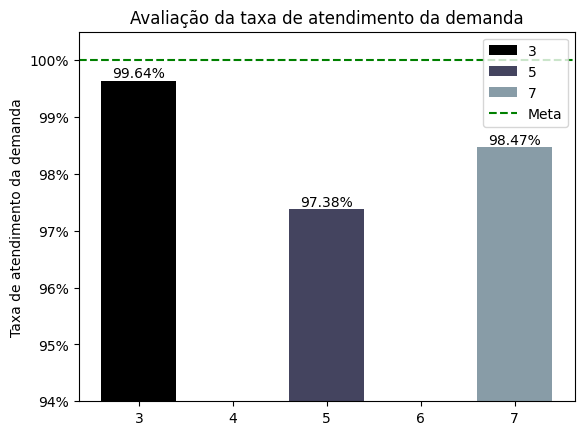

In [401]:
fig, ax = plt.subplots()

clientesAtendidos = clientesA['%atendidos']
cenarios = clientesA['num']
bar_labels = clientesA['num']

width = 0.25  # the width of the bars
multiplier = 0

# Fill with colors
values = bar_labels
cmap = cm.get_cmap('bone')
cmap = colors.ListedColormap([cmap(i) for i in range(0, cmap.N-100)])
rescale = lambda values: (values - np.min(values)) / (np.max(values) - np.min(values))

bar = ax.bar(cenarios,clientesAtendidos, label=bar_labels, color=cmap(rescale(values)))

# Adiciona as labels formatadas em porcentagem
ax.bar_label(bar, labels=[f'{val:.2f}%' for val in clientesAtendidos])

plt.axhline(100, color='green', linestyle='--', label=f'Meta')

# Formata o eixo y em porcentagem
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
   
ax.set_ylim([94, 100.5])
ax.set_ylabel('Taxa de atendimento da demanda')
ax.set_title('Avaliação da taxa de atendimento da demanda')
plt.legend()

plt.show()